In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# The adult.csv file has no header row, so we assign column names manually
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
           'marital_status', 'occupation', 'relationship', 'race', 'sex',
           'capital_gain', 'capital_loss', 'hours_per_week',
           'native_country', 'income']

df = pd.read_csv('adult.csv', header=None, names=columns, skipinitialspace=True)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Check target class distribution
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [7]:
df.shape

(32561, 15)

### Handle Missing Values

In [8]:
df= df.replace('?',np.nan)
df.isnull().sum()


age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [9]:
 df = df.dropna()
 df.shape

(30162, 15)

### Drop Weak / Redundant Columns


In [10]:
# fnlwgt = census sampling weight, has no predictive value
# education = redundant, since education_num already encodes it numerically
df = df.drop(['fnlwgt', 'education'], axis=1)
df.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Handle Skewed Numeric features 

In [11]:
# capital_gain and capital_loss are extremely skewed,
# log transform makes them more 'Gaussian-like', which Naive Bayes assumes 
df['capital_gain'] = np.log1p(df['capital_gain'])
df[['capital_gain', 'capital_loss']].describe()

,capital_gain,capital_loss
count,30162.000000,30162.000000
mean,0.743647,88.372489
std,2.470518,404.298370
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,11.512925,4356.000000


### Encode categorical columns 

In [12]:
# Encode categorical columns into numbers , except the target 
categorical_cols = df.select_dtypes (include= 'object').columns.drop('income')
label_encoders={}
for col in categorical_cols:
    le = LabelEncoder()
    df[col]= le.fit_transform(df[col])
    label_encoders[col] = le

In [13]:
# Encode the target variable
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
df.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,5,13,4,0,1,4,1,7.684784,0,40,38,0
1,50,4,13,2,3,0,4,1,0.000000,0,13,38,0
2,38,2,9,0,5,1,4,1,0.000000,0,40,38,0
3,53,2,7,2,5,0,2,1,0.000000,0,40,38,0
4,28,2,13,2,9,5,2,0,0.000000,0,40,4,0


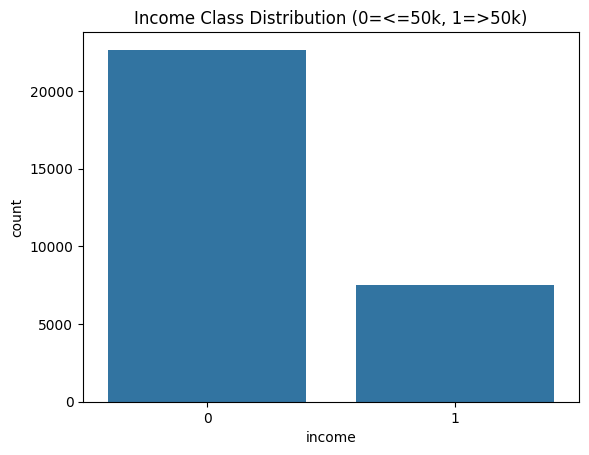

In [14]:
# Visualize the class Balance
sns.countplot (x = 'income', data = df)
plt.title("Income Class Distribution (0=<=50k, 1=>50k)")
plt.show()

In [15]:
# Split The Feature And Target 
x = df.drop('income', axis = 1)
y = df['income']
print ("Feature shape:", x.shape)
print ("Target shape:", y.shape)

Feature shape: (30162, 12)
Target shape: (30162,)


### Train-Test Split 

In [16]:
x_train , x_test , y_train , y_test = train_test_split(x,y , test_size = 0.2 ,random_state = 42, stratify=y)
print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 24129
Testing samples: 6033


### Feature Scaling 

In [17]:
# Naive Bayse(Gaussian) assume normally distributed feature,
# Scaling helps stabilized  the variance estimates.
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Train The Naive Bayes Model 


In [18]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(x_train_scaled , y_train)


,priors,None
,var_smoothing,1e-09


#### Make Prediction 

In [19]:
y_pred = model.predict(x_test_scaled)
y_pred[:20]


array([1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Evaluate the model

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision * 100:.2f}%")

recall = recall_score(y_test, y_pred)
print(f"Recall: {recall * 100:.2f}%")

f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1 * 100:.2f}%")

Accuracy: 80.47%
Precision: 62.94%
Recall: 52.46%
F1 Score: 57.23%


### Confusion Matrix


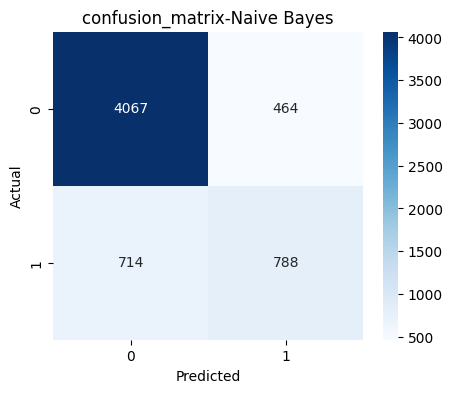

In [24]:
Cm = confusion_matrix (y_test , y_pred)
plt.figure(figsize = (5,4))
sns.heatmap(Cm, annot =True , fmt='d' , cmap ="Blues")
xtickslabels = ['50k', '>50k']
ytickslabels = ['<=50k', '>50k']
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion_matrix-Naive Bayes")
plt.show()

In [26]:
# Select the first sample from our test data

sample_index = 0

# Get that person's scaled features
# reshape(1, -1) changes the data into the
# format expected by the model.

sample = x_test_scaled[
    sample_index
].reshape(1, -1)

# Ask the model to predict the person's income

prediction = model.predict(
    sample
)[0]

# Get the real answer

actual = y_test.iloc[
    sample_index
]

In [27]:
# Display the model's prediction

print(
    "Predicted income class:",
    "> 50K" if prediction == 1 else "<= 50K"
)

# Display the actual income class

print(
    "Actual income class:   ",
    "> 50K" if actual == 1 else "<= 50K"
)

Predicted income class: > 50K
Actual income class:    <= 50K
